In [241]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, learning_curve
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    RBF,
    Matern,
    RationalQuadratic,
    WhiteKernel,
)
from sklearn.base import clone

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import shap

# Configuration
RANDOM_STATE = 4
KNN_NEIGHBORS = 5

In [242]:
df = pd.read_csv("../data/Data.csv")
print(f"Loaded shape: {df.shape}")

df.sample(10, random_state=RANDOM_STATE)

Loaded shape: (374, 8)


,MOF,Surface area (m2/g),Pore Volume (cm3/g),Catalyst dosage (g/L),Antibiotic dosage (mg/L),Illumination time (min),pH,Degradation (%)
172,MIL-101,252.59,0.860,0.50,30,40,8.00,56.6
319,MIL-100-PANI,950.00,0.300,0.25,10,15,3.00,10.7
336,MIL-100-PANI,950.00,0.300,0.25,10,120,5.00,18.7
14,MIL-101,180.41,0.320,0.15,50,20,4.10,83.0
202,PI-UiO-66-NH2,922.75,0.500,0.20,10,10,9.00,19.0
61,MIL-88A,15.95,0.110,0.50,200,20,3.45,46.1
317,MIL-100-PANI,950.00,0.300,0.25,10,135,2.00,100.0
128,MIL-88A,15.95,0.110,0.25,200,20,9.00,27.6
225,In2S3-MIL-125-Ti,303.90,0.464,0.30,46,60,5.90,64.1
281,AgI-UiO-66-NH2,425.88,0.273,0.30,10,0,5.50,9.8


In [243]:
buffer_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
})

buffer_info

,dtype,n_unique,n_missing
MOF,object,10,0
Surface area (m2/g),float64,13,0
Pore Volume (cm3/g),float64,13,0
Catalyst dosage (g/L),float64,12,0
Antibiotic dosage (mg/L),int64,7,0
Illumination time (min),int64,25,0
pH,float64,18,0
Degradation (%),float64,302,0


In [244]:
# Duplicate analysis
n_exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_duplicates}")

if n_exact_duplicates > 0:
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

Exact duplicate rows: 0


In [245]:
# UNIVARIATE EDA
TARGET_COL = "Degradation (%)"
EXACT_FEATURES = [
    "Surface area (m2/g)",
    "Pore Volume (cm3/g)",
    "Catalyst dosage (g/L)",
    "Antibiotic dosage (mg/L)",
    "Illumination time (min)",
    "pH",
]

X = df[EXACT_FEATURES].copy()
y = df[TARGET_COL].copy()

feature_names = X.columns.tolist()
NUMERIC_COLS = [col for col in X.columns if col != "MOF"]

UNIVARIATE DESCRIPTIVE STATISTICS


,Min,Max,Mean,Median,Std,Q1,Q3,IQR,Skewness,N Unique,N Obs
Variable,,,,,,,,,,,
Surface area (m2/g),15.95,1548.30,374.222,252.59,351.250,180.41,425.88,245.47,1.177,13,374
Pore Volume (cm3/g),0.11,0.86,0.353,0.30,0.247,0.20,0.32,0.12,1.190,13,374
Catalyst dosage (g/L),0.05,2.00,0.412,0.30,0.409,0.25,0.50,0.25,2.656,12,374
Antibiotic dosage (mg/L),10.00,200.00,66.588,40.00,74.552,10.00,50.00,40.00,1.142,7,374
Illumination time (min),0.00,360.00,43.810,30.00,46.320,10.00,60.00,50.00,2.260,25,374
pH,1.00,12.20,5.871,5.50,2.489,4.10,8.00,3.90,0.078,18,374


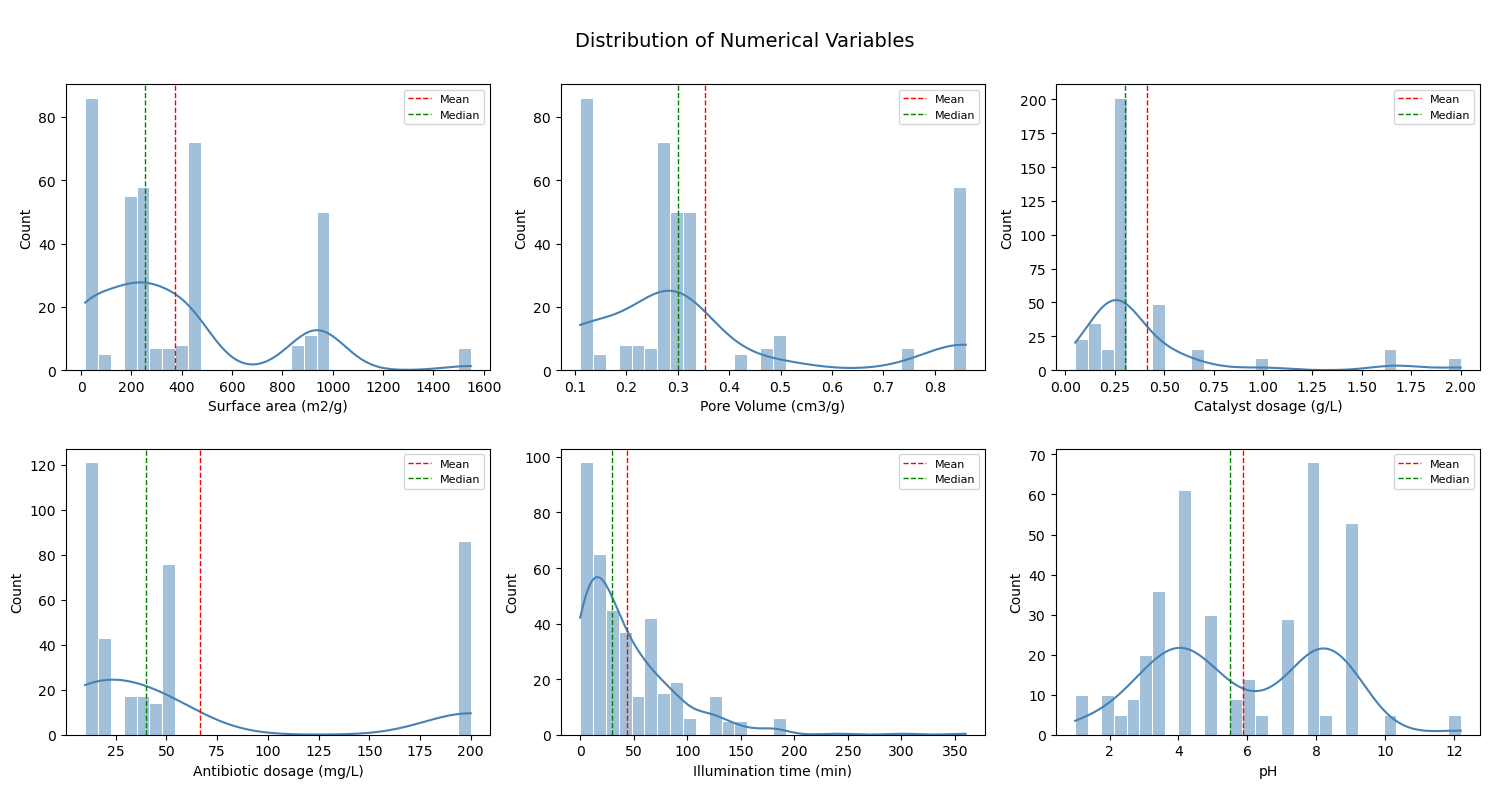

In [246]:
def compute_univariate_stats(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Compute descriptive statistics (min, max, mean, median, std, IQR, skew, n_unique)."""
    rows = []
    for col in cols:
        series = pd.to_numeric(df[col], errors="coerce").dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        rows.append({
            "Variable": col,
            "Min": series.min(),
            "Max": series.max(),
            "Mean": series.mean(),
            "Median": series.median(),
            "Std": series.std(),
            "Q1": q1,
            "Q3": q3,
            "IQR": q3 - q1,
            "Skewness": stats.skew(series),
            "N Unique": series.nunique(),
            "N Obs": series.shape[0],
        })

    stats_df = pd.DataFrame(rows).set_index("Variable").round(3)
    return stats_df


def plot_univariate_distributions(
    df: pd.DataFrame,
    cols: list[str],
    bins: int = 30,
    ncols: int = 3,
) -> None:
    """Plot histogram + KDE for each numeric column in a grid."""
    n = len(cols)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        sns.histplot(series, bins=bins, kde=True, ax=ax, color="steelblue", edgecolor="white")
        ax.axvline(series.mean(), color="red", linestyle="--", linewidth=1, label="Mean")
        ax.axvline(series.median(), color="green", linestyle="--", linewidth=1, label="Median")
        ax.set_title(" ")
        ax.set_xlabel(col)
        ax.legend(fontsize=8)

    # Hide any unused subplots
    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle("\nDistribution of Numerical Variables", fontsize=14)
    plt.tight_layout()
    plt.show()


# Execute Phase
univariate_stats = compute_univariate_stats(df, NUMERIC_COLS)
print("UNIVARIATE DESCRIPTIVE STATISTICS")
display(univariate_stats)

# Distribution plots
plot_univariate_distributions(df, NUMERIC_COLS, bins=30, ncols=3)

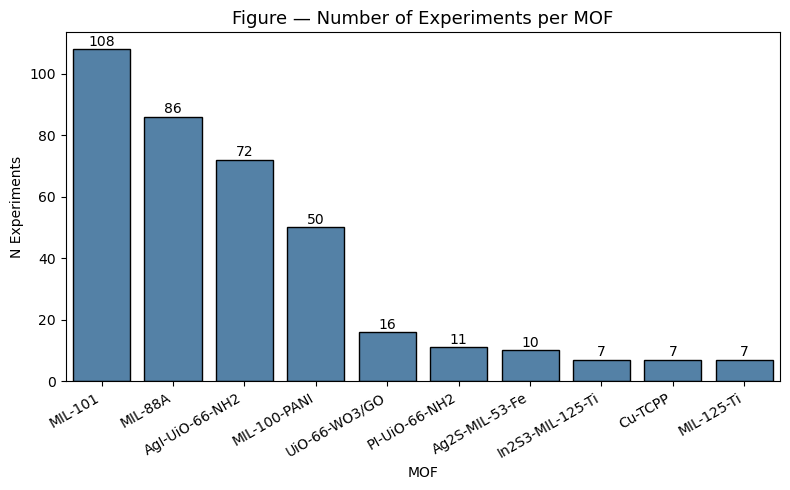

In [247]:
# Analyze MOFs (CATEGORICAL)
def plot_categorical_distribution(
    df: pd.DataFrame,
    col: str,
    order: list[str] | None = None,
    annotate: bool = True,
) -> None:
    """Bar plot of counts per category, ordered by frequency."""
    counts = df[col].value_counts()
    if order is None:
        order = counts.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        x=counts.loc[order].index,
        y=counts.loc[order].values,
        order=order,
        color="steelblue",
        edgecolor="black",
        ax=ax,
    )

    if annotate:
        for i, val in enumerate(counts.loc[order].values):
            ax.text(i, val + counts.max() * 0.01, str(val), ha="center", fontsize=10)

    ax.set_title(f"Figure — Number of Experiments per {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("N Experiments")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Execute
plot_categorical_distribution(df, "MOF")

In [248]:
df.drop(columns=["MOF"], inplace=True)

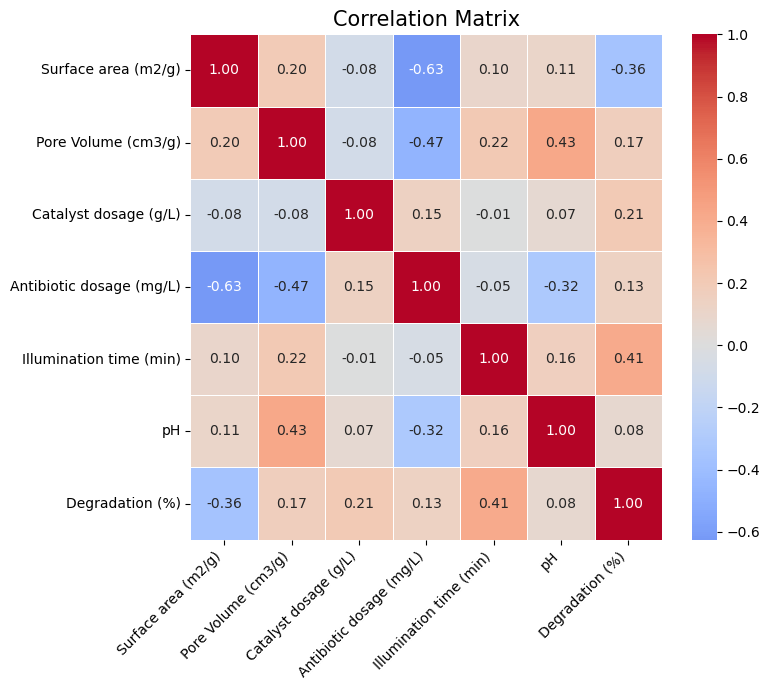

In [249]:
# CORRELATION MATRIX

corr_matrix = df.corr()

plt.figure(figsize=(8, 7))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [250]:
# VIF CHECK

# Remove target
X_vif = df.drop(columns=[TARGET_COL]).copy()

# Keep numeric variables only
X_vif = X_vif.select_dtypes(include=[np.number])

# Add intercept
X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

# Remove intercept from results
vif_data = vif_data[vif_data["Variable"] != "const"]

# Sort highest to lowest
vif_data = (
    vif_data
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

display(vif_data.round(3))

,Variable,VIF
0,Antibiotic dosage (mg/L),2.189
1,Surface area (m2/g),1.716
2,Pore Volume (cm3/g),1.517
3,pH,1.290
4,Illumination time (min),1.082
5,Catalyst dosage (g/L),1.041


In [251]:


feature_names = X.columns.tolist()
feature_names

['Surface area (m2/g)',
 'Pore Volume (cm3/g)',
 'Catalyst dosage (g/L)',
 'Antibiotic dosage (mg/L)',
 'Illumination time (min)',
 'pH']

In [252]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)
n_features = X.shape[1]

In [253]:
# 4. GPR KERNELS

kernels = {

    # Matern kernel
    "GPR Matern": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3)
        )
        *
        Matern(
            length_scale=1.0,
            length_scale_bounds=(1e-3, 1e3),
            nu=1.5
        )
        +
        WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)
        )
    ),

    # Exponential kernel = Matern nu = 0.5
    "GPR Exp": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3)
        )
        *
        Matern(
            length_scale=1.0,
            length_scale_bounds=(1e-3, 1e3),
            nu=0.5
        )
        +
        WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)
        )
    ),

    # Squared exponential kernel
    "GPR SExp": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3)
        )
        *
        RBF(
            length_scale=1.0,
            length_scale_bounds=(1e-3, 1e3)
        )
        +
        WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)
        )
    ),

    # Rational quadratic kernel
    "GPR Rational Quadratic": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3)
        )
        *
        RationalQuadratic(
            length_scale=1.0,
            alpha=1.0,
            length_scale_bounds=(1e-3, 1e3),
            alpha_bounds=(1e-3, 1e3)
        )
        +
        WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)
        )
    ),
}

In [254]:
# 5. BUILD GPR PIPELINE
# ============================================================

def make_gpr_model(kernel):

    steps = []


    steps.append(
        ("scaler", StandardScaler())
    )

    steps.append(
        (
            "gpr",
            GaussianProcessRegressor(
                kernel=clone(kernel),

                # Noise is already represented by WhiteKernel
                alpha=0.0,

                normalize_y=True,

                n_restarts_optimizer=15,

                random_state=RANDOM_STATE
            )
        )
    )

    return Pipeline(steps)

In [255]:
# 6. PERFORMANCE METRICS
def regression_metrics(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    residuals = y_true - y_pred

    r2 = r2_score(y_true, y_pred)

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    # Mean Relative Error
    denominator = np.where(
        np.abs(y_true) < 1e-12,
        np.nan,
        np.abs(y_true)
    )

    mre = np.nanmean(
        np.abs(y_pred - y_true) / denominator
    ) * 100

    # Standard deviation of residual errors
    std = np.std(
        residuals,
        ddof=0
    )

    return {
        "R²": r2,
        "MRE (%)": mre,
        "MSE": mse,
        "RMSE": rmse,
        "STD": std,
    }

In [256]:
# 7. FIT AND EVALUATE ALL GPR MODELS
# ============================================================

fitted_models = {}
results = []

for model_name, kernel in kernels.items():

    print("=" * 70)
    print(model_name)

    model = make_gpr_model(kernel)

    # Train
    model.fit(
        X_train,
        y_train
    )

    fitted_models[model_name] = model

    # --------------------------------------------------------
    # Predictions
    # IMPORTANT:
    # Do NOT clip predictions here.
    # --------------------------------------------------------

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_total_pred = model.predict(X)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    train_metrics = regression_metrics(
        y_train,
        y_train_pred
    )

    test_metrics = regression_metrics(
        y_test,
        y_test_pred
    )

    total_metrics = regression_metrics(
        y,
        y_total_pred
    )

    for dataset_name, metrics in [
        ("Train", train_metrics),
        ("Test", test_metrics),
        ("Total", total_metrics)
    ]:

        results.append({
            "Model": model_name,
            "Dataset": dataset_name,
            **metrics
        })

    # --------------------------------------------------------
    # Show optimized kernel
    # --------------------------------------------------------

    optimized_kernel = (
        model
        .named_steps["gpr"]
        .kernel_
    )

    print("Optimized kernel:")
    print(optimized_kernel)

    print(
        f"Train R² = {train_metrics['R²']:.4f}"
    )

    print(
        f"Test  R² = {test_metrics['R²']:.4f}"
    )

    print(
        f"Test RMSE = {test_metrics['RMSE']:.4f}"
    )

GPR Matern
Optimized kernel:
2.13**2 * Matern(length_scale=2.28, nu=1.5) + WhiteKernel(noise_level=0.026)
Train R² = 0.9874
Test  R² = 0.8764
Test RMSE = 10.4815
GPR Exp
Optimized kernel:
2.97**2 * Matern(length_scale=22.2, nu=0.5) + WhiteKernel(noise_level=0.00117)
Train R² = 1.0000
Test  R² = 0.8508
Test RMSE = 11.5161
GPR SExp
Optimized kernel:
1.52**2 * RBF(length_scale=0.906) + WhiteKernel(noise_level=0.0323)
Train R² = 0.9805
Test  R² = 0.8766
Test RMSE = 10.4724
GPR Rational Quadratic
Optimized kernel:
2.27**2 * RationalQuadratic(alpha=0.385, length_scale=1.51) + WhiteKernel(noise_level=0.0291)
Train R² = 0.9836
Test  R² = 0.8818
Test RMSE = 10.2522


In [257]:
# 8. RESULTS TABLE
# ============================================================

gpr_results = pd.DataFrame(results)

for col in [
    "R²",
    "MRE (%)",
    "MSE",
    "RMSE",
    "STD"
]:
    gpr_results[col] = gpr_results[col].astype(float)


table_1_df = (
    gpr_results
    .set_index(["Model", "Dataset"])
    .round({
        "R²": 3,
        "MRE (%)": 2,
        "MSE": 2,
        "RMSE": 2,
        "STD": 2
    })
)

print(
    "\nTABLE 1: Statistical Parameters "
    "of Suggested GPR Models"
)

display(table_1_df)


TABLE 1: Statistical Parameters of Suggested GPR Models


R²  MRE (%)     MSE   RMSE    STD
Model                  Dataset                                      
GPR Matern             Train    0.987     7.60   10.51   3.24   3.24
                       Test     0.876    57.38  109.86  10.48  10.19
                       Total    0.964    17.59   30.44   5.52   5.49
GPR Exp                Train    1.000     0.31    0.02   0.13   0.13
                       Test     0.851    60.80  132.62  11.52  11.13
                       Total    0.969    12.44   26.61   5.16   5.12
GPR SExp               Train    0.981    10.89   16.22   4.03   4.03
                       Test     0.877    59.02  109.67  10.47  10.27
                       Total    0.959    20.54   34.96   5.91   5.90
GPR Rational Quadratic Train    0.984     8.91   13.66   3.70   3.70
                       Test     0.882    57.52  105.11  10.25  10.02
                       Total    0.962    18.66   32.00   5.66   5.64

In [258]:
# 3. METRIC FORMULAS (EQUATIONS 1-5 IN THE PAPER)
def compute_paper_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    n = len(y_true)

    r2 = r2_score(y_true, y_pred)
    safe_true = np.where(y_true == 0, 1e-6, y_true)
    mre = (1.0 / n) * np.sum(np.abs(y_pred - y_true) / safe_true) * 100.0
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    std_err = np.std(y_true - y_pred)

    return {"R²": r2, "MRE (%)": mre, "MSE": mse, "RMSE": rmse, "STD": std_err}

In [259]:
# 4. FIT PIPELINE & REPRODUCE TABLE 1
fitted_models = {}
eval_rows = []

for name, kernel in kernels.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("gpr", GaussianProcessRegressor(
            kernel=kernel,
            alpha=0.0,  # WhiteKernel handles observation noise directly
            normalize_y=True,
            n_restarts_optimizer=15,
            random_state=RANDOM_STATE
        ))
    ])

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    # Predictions clipped to physically realistic range [0, 100]%
    y_tr_pred = np.clip(pipe.predict(X_train), 0.0, 100.0)
    y_te_pred = np.clip(pipe.predict(X_test), 0.0, 100.0)

    X_tot = pd.concat([X_train, X_test])
    y_tot = pd.concat([y_train, y_test])
    y_tot_pred = np.clip(pipe.predict(X_tot), 0.0, 100.0)

    for split_name, yt, yp in [("Train", y_train, y_tr_pred),
                               ("Test", y_test, y_te_pred),
                               ("Total", y_tot, y_tot_pred)]:
        m = compute_paper_metrics(yt, yp)
        eval_rows.append({
            "Model": name,
            "Dataset": split_name,
            "R²": round(m["R²"], 3),
            "MRE (%)": round(m["MRE (%)"], 2),
            "MSE": round(m["MSE"], 2),
            "RMSE": round(m["RMSE"], 2),
            "STD": round(m["STD"], 2)
        })

table_1_df = pd.DataFrame(eval_rows).set_index(["Model", "Dataset"])
print("\nTABLE 1: Statistical Parameters of Suggested GPR Models")
display(table_1_df)

KeyboardInterrupt: 

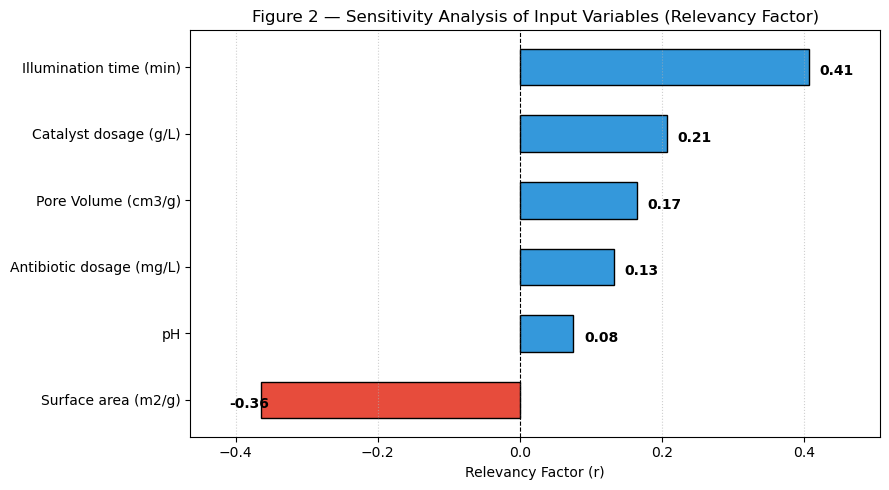

In [ ]:
# 5. SENSITIVITY ANALYSIS: RELEVANCY FACTOR (EQUATION 24 & FIGURE 2)
# =====================================================================
def compute_relevancy_factor(X_df: pd.DataFrame, y_sr: pd.Series) -> pd.Series:
    """Eq. (24): Pearson correlation-based Relevancy Factor (r) for each input."""
    X_mean = X_df.mean()
    y_mean = y_sr.mean()

    numerator = ((X_df - X_mean).multiply(y_sr - y_mean, axis=0)).sum()
    denominator = np.sqrt(((X_df - X_mean) ** 2).sum() * np.sum((y_sr - y_mean) ** 2))
    return numerator / denominator

relevancy_scores = compute_relevancy_factor(X, y).sort_values()

plt.figure(figsize=(9, 5))
colors = ["#e74c3c" if val < 0 else "#3498db" for val in relevancy_scores.values]
bars = plt.barh(relevancy_scores.index, relevancy_scores.values, color=colors, edgecolor="black", height=0.55)
plt.axvline(0, color="black", linestyle="--", lw=0.8)

for bar in bars:
    w = bar.get_width()
    offset = 0.015 if w >= 0 else -0.045
    plt.text(w + offset, bar.get_y() + 0.15, f"{w:.2f}", fontsize=10, fontweight="bold")

plt.title("Figure 2 — Sensitivity Analysis of Input Variables (Relevancy Factor)", fontsize=12)
plt.xlabel("Relevancy Factor (r)")
plt.xlim(min(relevancy_scores.values) - 0.1, max(relevancy_scores.values) + 0.1)
plt.grid(True, axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

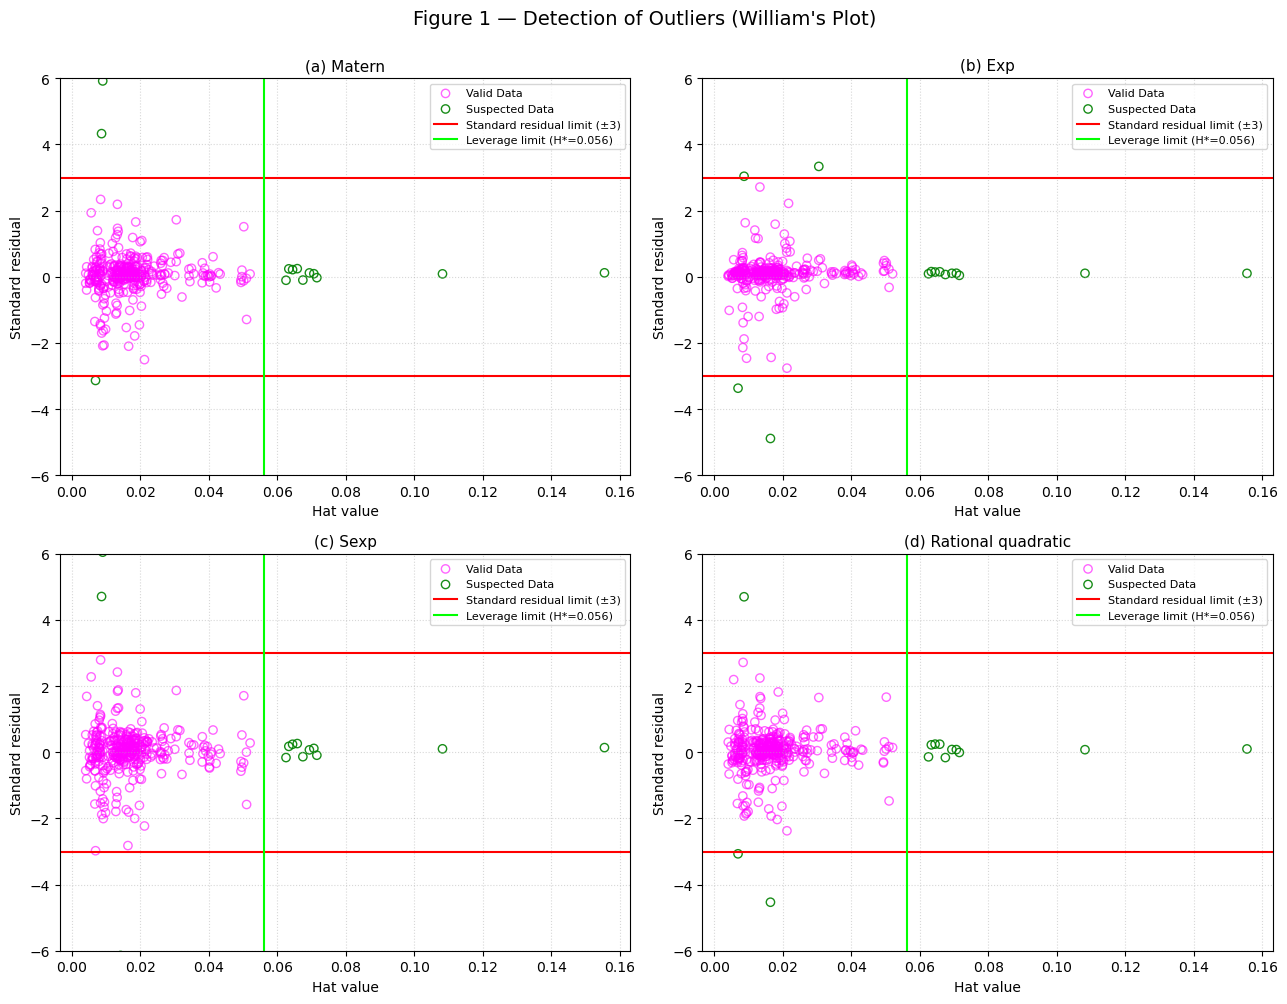

In [ ]:
# 6. LEVERAGE OUTLIER DETECTION: WILLIAM'S PLOT (FIGURE 1 & EQS. 22-23)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# Hat matrix Leverage threshold: H* = 3(k + 1) / n
n_samples, n_params = X.shape[0], X.shape[1]
h_star = 3.0 * (n_params + 1) / n_samples

X_mat = np.column_stack([np.ones(n_samples), StandardScaler().fit_transform(X)])
H = X_mat @ np.linalg.pinv(X_mat.T @ X_mat) @ X_mat.T
hat_values = np.diag(H)

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    y_pred_all = model_pipe.predict(X)
    residuals = y.values - y_pred_all
    std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

    # Classify valid vs suspected
    is_outlier = (np.abs(std_residuals) > 3) | (hat_values > h_star)
    
    ax.scatter(hat_values[~is_outlier], std_residuals[~is_outlier], 
               facecolors="none", edgecolors="magenta", label="Valid Data", alpha=0.6)
    ax.scatter(hat_values[is_outlier], std_residuals[is_outlier], 
               facecolors="none", edgecolors="green", label="Suspected Data", alpha=0.9)

    ax.axhline(3, color="red", linestyle="-", lw=1.5, label="Standard residual limit (±3)")
    ax.axhline(-3, color="red", linestyle="-", lw=1.5)
    ax.axvline(h_star, color="lime", linestyle="-", lw=1.5, label=f"Leverage limit (H*={h_star:.3f})")

    ax.set_title(f"({chr(97 + idx)}) {model_name.replace('GPR ', '').capitalize()}", fontsize=11)
    ax.set_xlabel("Hat value")
    ax.set_ylabel("Standard residual")
    ax.set_ylim(-6, 6)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Figure 1 — Detection of Outliers (William's Plot)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

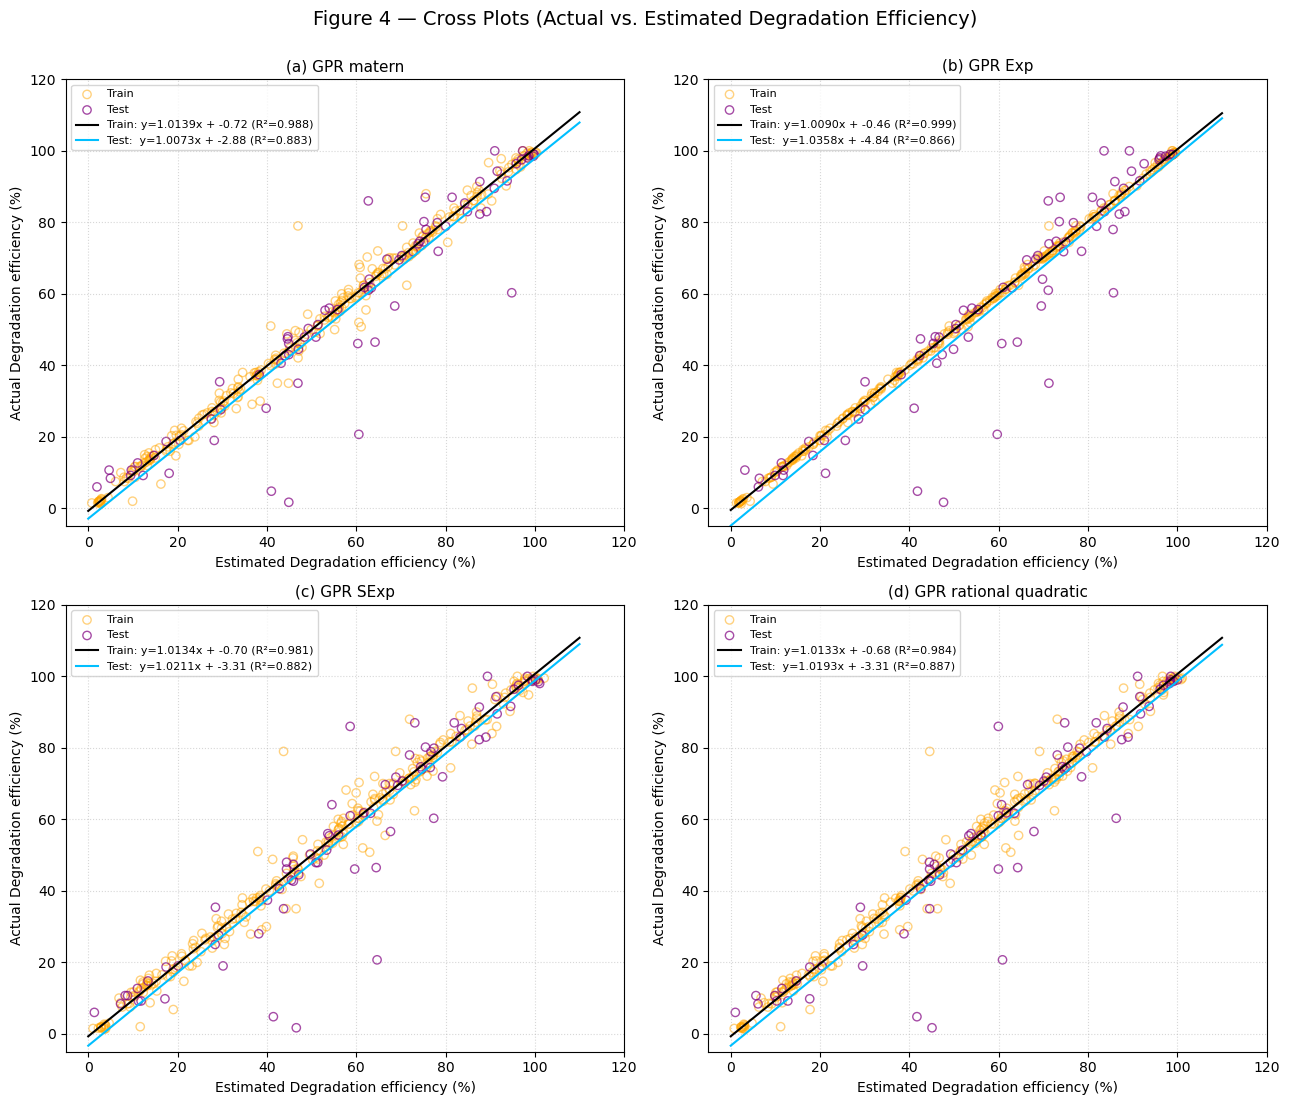

In [ ]:
# 7. CROSS-PLOTS & LINEAR REGRESSION FITS (FIGURE 4)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    
    # Train fit line
    y_tr_pred = model_pipe.predict(X_train)
    slope_tr, intercept_tr, r_val_tr, _, _ = stats.linregress(y_tr_pred, y_train)
    
    # Test fit line
    y_te_pred = model_pipe.predict(X_test)
    slope_te, intercept_te, r_val_te, _, _ = stats.linregress(y_te_pred, y_test)

    ax.scatter(y_tr_pred, y_train, facecolors="none", edgecolors="orange", alpha=0.5, label="Train")
    ax.scatter(y_te_pred, y_test, facecolors="none", edgecolors="purple", alpha=0.7, label="Test")

    x_domain = np.linspace(0, 110, 100)
    ax.plot(x_domain, slope_tr * x_domain + intercept_tr, color="black", lw=1.5, 
            label=f"Train: y={slope_tr:.4f}x + {intercept_tr:.2f} (R²={r_val_tr**2:.3f})")
    ax.plot(x_domain, slope_te * x_domain + intercept_te, color="deepskyblue", lw=1.5, 
            label=f"Test:  y={slope_te:.4f}x + {intercept_te:.2f} (R²={r_val_te**2:.3f})")

    ax.set_title(f"({chr(97 + idx)}) {model_name}", fontsize=11)
    ax.set_xlabel("Estimated Degradation efficiency (%)")
    ax.set_ylabel("Actual Degradation efficiency (%)")
    ax.set_xlim(-5, 120)
    ax.set_ylim(-5, 120)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Figure 4 — Cross Plots (Actual vs. Estimated Degradation Efficiency)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

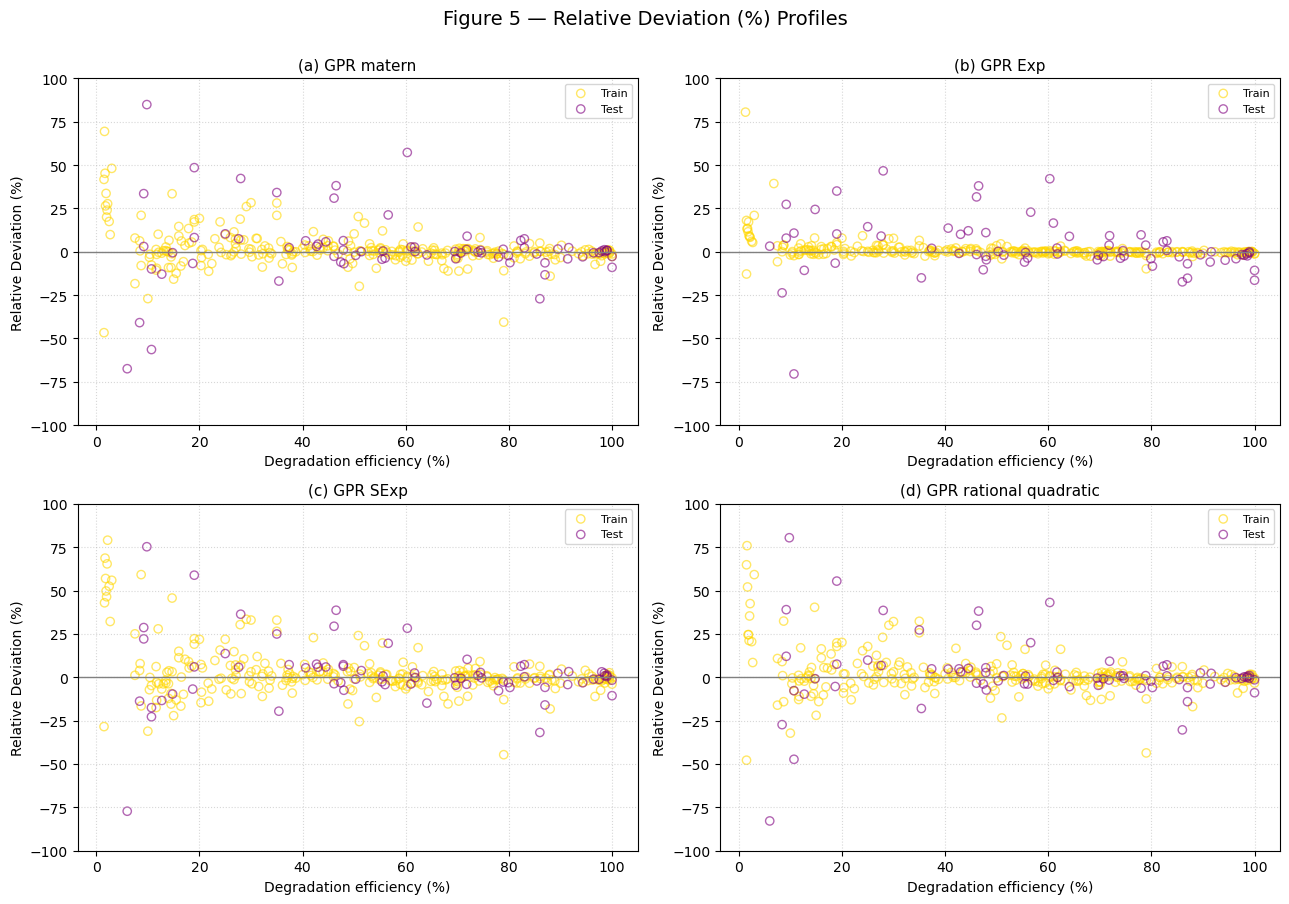

In [ ]:
# 8. RELATIVE DEVIATION PROFILES (FIGURE 5)
# =====================================================================
# Relative Deviation (%) = (y_pred - y_true) / y_true * 100
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    
    y_tr_pred = model_pipe.predict(X_train)
    y_te_pred = model_pipe.predict(X_test)
    
    dev_tr = ((y_tr_pred - y_train.values) / np.where(y_train.values == 0, 1e-6, y_train.values)) * 100
    dev_te = ((y_te_pred - y_test.values) / np.where(y_test.values == 0, 1e-6, y_test.values)) * 100

    ax.scatter(y_train, dev_tr, facecolors="none", edgecolors="gold", alpha=0.6, label="Train")
    ax.scatter(y_test, dev_te, facecolors="none", edgecolors="purple", alpha=0.6, label="Test")
    ax.axhline(0, color="gray", lw=1)

    ax.set_title(f"({chr(97 + idx)}) {model_name}", fontsize=11)
    ax.set_xlabel("Degradation efficiency (%)")
    ax.set_ylabel("Relative Deviation (%)")
    ax.set_ylim(-100, 100)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Figure 5 — Relative Deviation (%) Profiles", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
best_model = grid_search.best_estimator_
print(f"Best CV R²: {grid_search.best_score_:.4f}")
print(f"Best Kernel: {best_model.named_steps['gpr'].kernel_}")

Best CV R²: 0.9240
Best Kernel: 2.18**2 * Matern(length_scale=[2.54, 1.84, 5.18, 2.99, 2.33, 1.85], nu=1.5) + WhiteKernel(noise_level=0.0323)


In [ ]:
# PREDICTIVE UNCERTAINTY HELPER & EVALUATION
def gpr_predict_with_std(pipeline: Pipeline, X_data: pd.DataFrame):
    """Extract standard errors through pipeline feature scaling."""
    X_scaled = pipeline.named_steps["scaler"].transform(X_data)
    return pipeline.named_steps["gpr"].predict(X_scaled, return_std=True)

y_pred_train, y_std_train = gpr_predict_with_std(best_model, X_train)
y_pred_test, y_std_test = gpr_predict_with_std(best_model, X_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f"\n Test Performance ")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MSE      : {mse:.4f}")


 Test Performance 
R² Score : 0.9601
RMSE     : 5.9564
MSE      : 35.4788


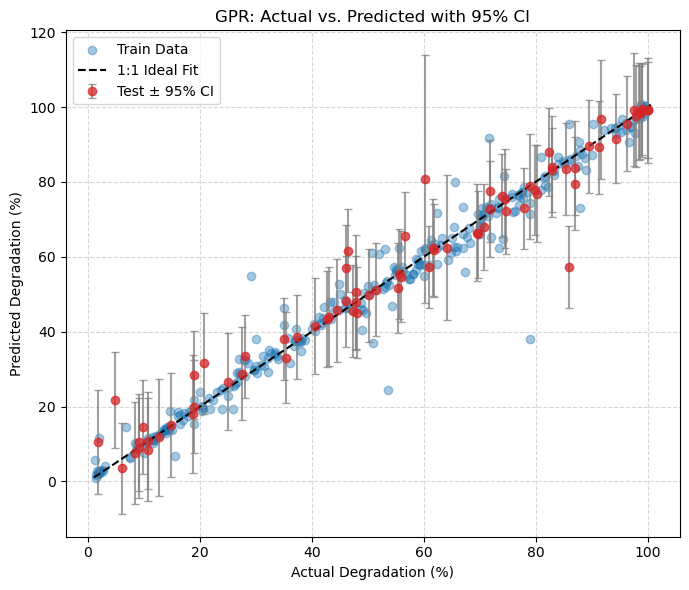

In [ ]:
# Actual vs Predicted with 95% Confidence Interval
plt.figure(figsize=(7, 6))
plt.scatter(y_train, y_pred_train, alpha=0.4, color="#1f77b4", label="Train Data")
plt.errorbar(
    y_test, y_pred_test,
    yerr=1.96 * y_std_test,
    fmt="o", alpha=0.75, color="#d62728", ecolor="gray", capsize=3,
    label="Test ± 95% CI"
)
all_vals = np.concatenate([y_train, y_test, y_pred_train, y_pred_test])
min_val, max_val = all_vals.min(), all_vals.max()
plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5, label="1:1 Ideal Fit")
plt.xlabel("Actual Degradation (%)")
plt.ylabel("Predicted Degradation (%)")
plt.title("GPR: Actual vs. Predicted with 95% CI")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


ARD Kernel Relevance:


,Feature,Length_Scale,ARD_Relevance (1/length_scale)
1,Pore Volume (cm3/g),1.838,0.544
5,pH,1.846,0.542
4,Illumination time (min),2.326,0.430
0,Surface area (m2/g),2.541,0.393
3,Antibiotic dosage (mg/L),2.995,0.334
2,Catalyst dosage (g/L),5.177,0.193


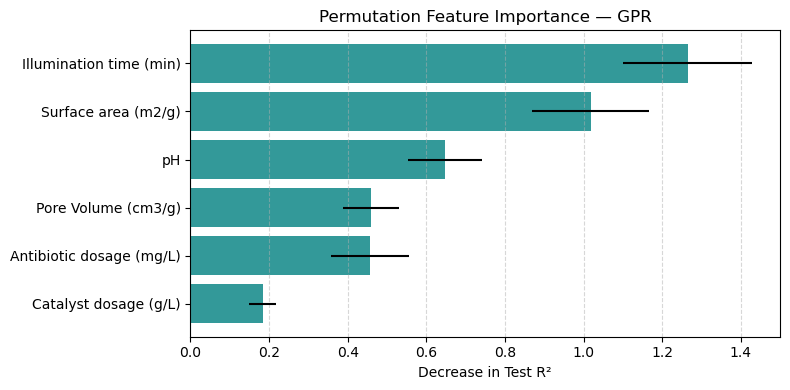

In [ ]:
# 6. FEATURE RELEVANCE (GPR LENGTH-SCALES & PERMUTATION IMPORTANCE)
# Method A: Kernel Length Scales (Automatic Relevance Determination)
# Smaller length scale -> feature varies more rapidly -> higher sensitivity
fitted_kernel = best_model.named_steps["gpr"].kernel_
if hasattr(fitted_kernel, "k1") and hasattr(fitted_kernel.k1, "k2"):
    ard_scales = fitted_kernel.k1.k2.length_scale
    ard_importance = pd.DataFrame({
        "Feature": feature_names,
        "Length_Scale": ard_scales,
        "ARD_Relevance (1/length_scale)": 1.0 / ard_scales
    }).sort_values("ARD_Relevance (1/length_scale)", ascending=False)
    print("\nARD Kernel Relevance:")
    display(ard_importance.round(3))

# Method B: Permutation Importance
perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="r2"
)
perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.barh(perm_df["Feature"], perm_df["Importance_Mean"], xerr=perm_df["Importance_Std"], color="teal", alpha=0.8)
plt.gca().invert_yaxis()
plt.xlabel("Decrease in Test R²")
plt.title("Permutation Feature Importance — GPR")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

100%|██████████| 75/75 [00:00<00:00, 114.39it/s]


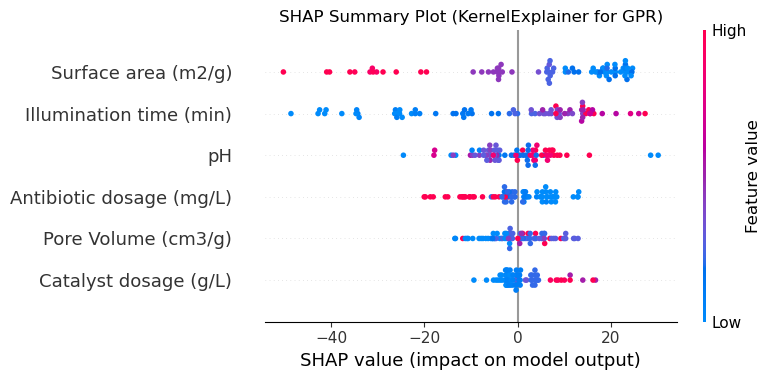

In [ ]:
# 7. SHAP EXPLANATION (MODEL-AGNOSTIC KERNEL EXPLAINER)
# Use a k-means background summary of train data to keep compute fast
background_summary = shap.kmeans(best_model.named_steps["scaler"].transform(X_train), k=15)
gpr_step = best_model.named_steps["gpr"]

explainer = shap.KernelExplainer(gpr_step.predict, background_summary)
X_test_scaled = best_model.named_steps["scaler"].transform(X_test)
shap_values = explainer.shap_values(X_test_scaled, nsamples=100)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (KernelExplainer for GPR)")
plt.tight_layout()
plt.show()